<a href="https://colab.research.google.com/github/Fragoa/Dimension-Reduction-with-MNIST/blob/main/DRWM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Flatten, Reshape
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
|(X_train, y_train), (X_test, y_test) = mnist.load_data()
X = np.concatenate((X_train, X_test))
y = np.concatenate((y_train, y_test))

# Normalize and flatten for PCA and MLPs
X_flat = X.reshape((X.shape[0], -1)) / 255.0
X_cnn = X.astype("float32") / 255.0
X_cnn = np.expand_dims(X_cnn, -1)  # for CNN input

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


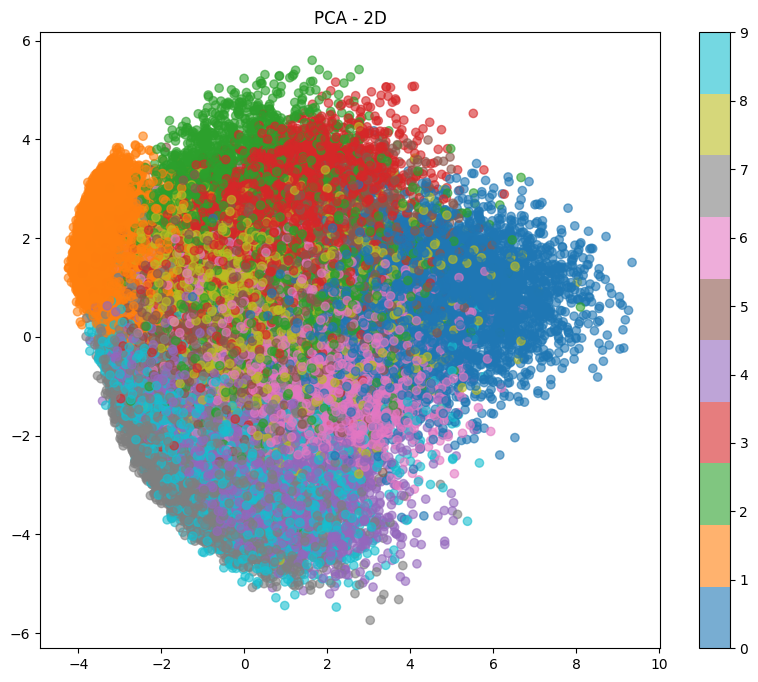

In [ ]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_flat)

plt.figure(figsize=(10, 8))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='tab10', alpha=0.6)
plt.colorbar()
plt.title("PCA - 2D")
plt.show()

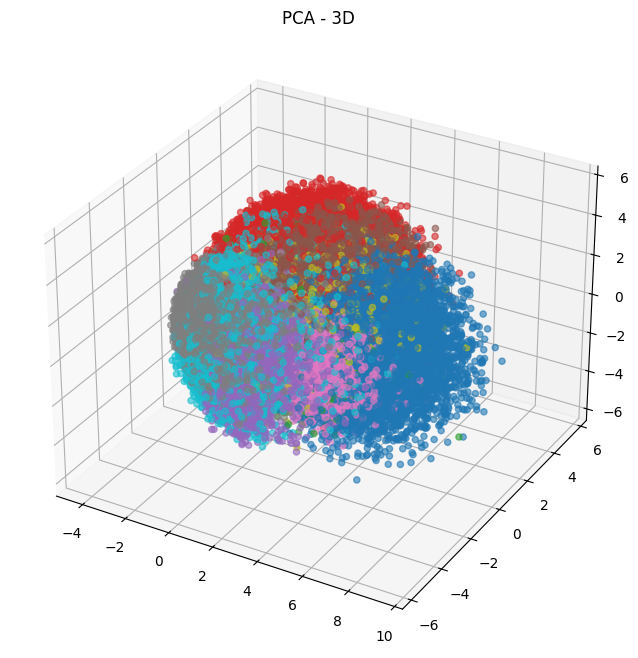

In [ ]:
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_flat)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=y, cmap='tab10', alpha=0.6)
plt.title("PCA - 3D")
plt.show()

In [ ]:
input_img = Input(shape=(784,))
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)
bottleneck = Dense(2, activation='linear')(encoded)  # 2 neurons

decoded = Dense(64, activation='relu')(bottleneck)
decoded = Dense(128, activation='relu')(decoded)
output = Dense(784, activation='sigmoid')(decoded)

In [ ]:
autoencoder = Model(input_img, output)
encoder = Model(input_img, bottleneck)

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_flat, X_flat, epochs=20, batch_size=256, shuffle=True)

X_encoded_2d = encoder.predict(X_flat)

Epoch 1/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.1008
Epoch 2/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0530
Epoch 3/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0486
Epoch 4/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0465
Epoch 5/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0453
Epoch 6/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0442
Epoch 7/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0435
Epoch 8/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0428
Epoch 9/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0421
Epoch 10/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0417
Epoch 11/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0411
Epoch 12/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0408
Epoch 13/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0404
Epoch 14/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0400
Epoch 15/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s

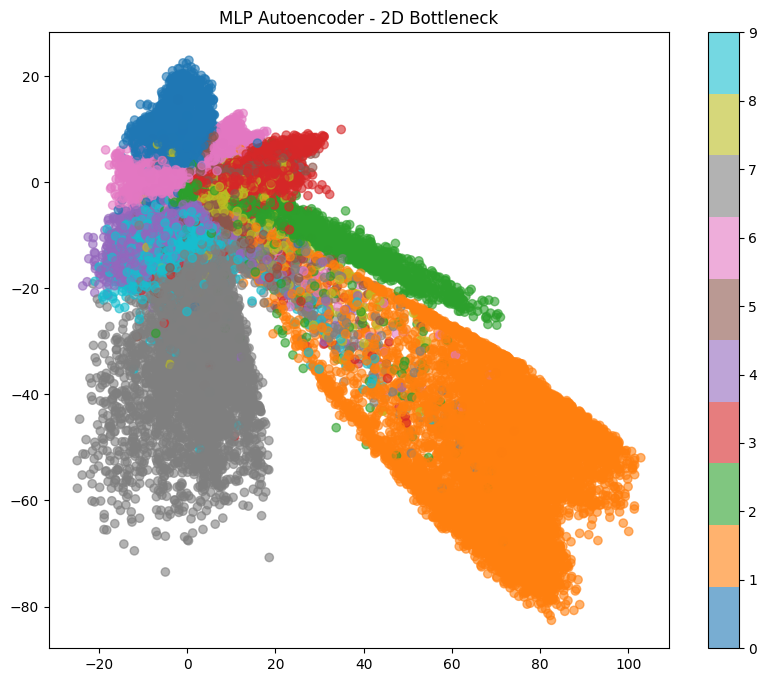

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(X_encoded_2d[:, 0], X_encoded_2d[:, 1], c=y, cmap='tab10', alpha=0.6)
plt.title("MLP Autoencoder - 2D Bottleneck")
plt.colorbar()
plt.show()

In [ ]:
# Similar to above, just change bottleneck layer
bottleneck = Dense(3, activation='linear')(encoded)
# (rest is the same...)

encoder = Model(input_img, bottleneck)
autoencoder = Model(input_img, output)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_flat, X_flat, epochs=20, batch_size=256, shuffle=True)

X_encoded_3d = encoder.predict(X_flat)

Epoch 1/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - loss: 0.0384
Epoch 2/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: 0.0383
Epoch 3/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0380
Epoch 4/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0380
Epoch 5/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0378
Epoch 6/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0376
Epoch 7/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0374
Epoch 8/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0375
Epoch 9/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0373
Epoch 10/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0372
Epoch 11/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0372
Epoch 12/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0370
Epoch 13/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0370
Epoch 14/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0371
Epoch 15/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 

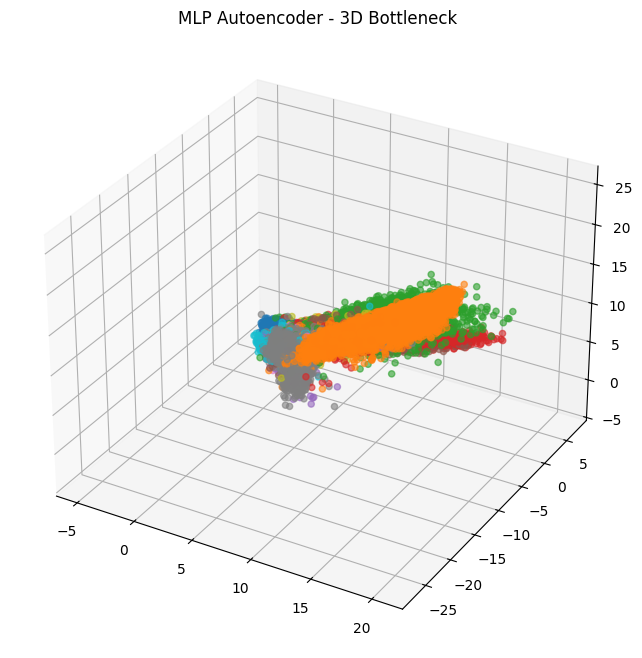

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_encoded_3d[:, 0], X_encoded_3d[:, 1], X_encoded_3d[:, 2], c=y, cmap='tab10', alpha=0.6)
plt.title("MLP Autoencoder - 3D Bottleneck")
plt.show()

In [ ]:
input_img = Input(shape=(28, 28, 1))
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Flatten()(x)
bottleneck = Dense(2)(x)  # 2 neurons

# Decoder
x = Dense(7 * 7 * 16, activation='relu')(bottleneck)
x = Reshape((7, 7, 16))(x)
x = UpSampling2D((2, 2))(x)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
encoder = Model(input_img, bottleneck)

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_cnn, X_cnn, epochs=20, batch_size=256, shuffle=True)

X_encoded_cnn2d = encoder.predict(X_cnn)

Epoch 1/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 91s 313ms/step - loss: 0.1056
Epoch 2/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 81s 295ms/step - loss: 0.0578
Epoch 3/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 78s 286ms/step - loss: 0.0536
Epoch 4/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 86s 315ms/step - loss: 0.0521
Epoch 5/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 135s 290ms/step - loss: 0.0510
Epoch 6/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 84s 296ms/step - loss: 0.0502
Epoch 7/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 80s 290ms/step - loss: 0.0494
Epoch 8/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 82s 298ms/step - loss: 0.0488
Epoch 9/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 81s 294ms/step - loss: 0.0484
Epoch 10/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 80s 291ms/step - loss: 0.0479
Epoch 11/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 82s 291ms/step - loss: 0.0474
Epoch 12/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 82s 290ms/step - loss: 0.0471
Epoch 13/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 81s 286ms/step - loss: 0.0467
Epoch 14/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 83s 290ms/step - loss: 0.0466
Epoch 15/20
27

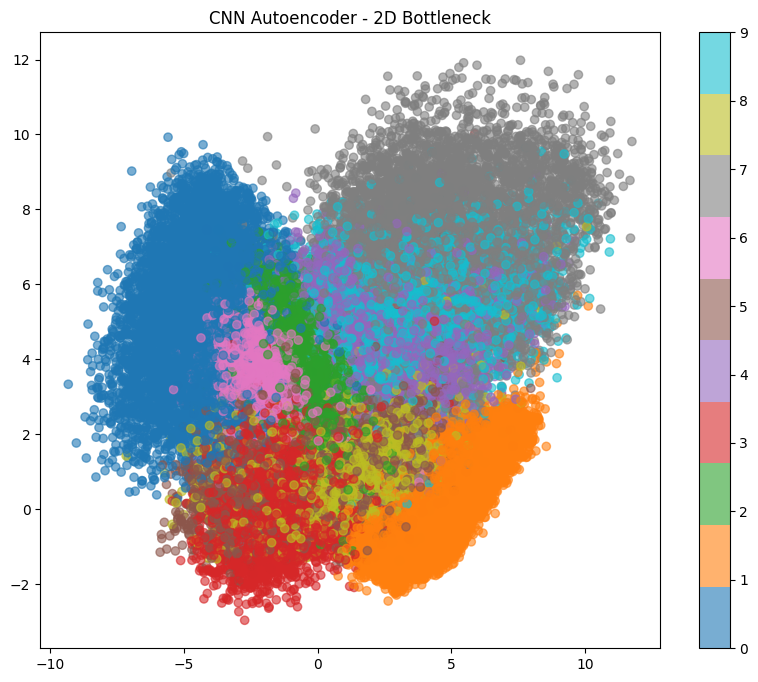

In [15]:
plt.figure(figsize=(10, 8))
plt.scatter(X_encoded_cnn2d[:, 0], X_encoded_cnn2d[:, 1], c=y, cmap='tab10', alpha=0.6)
plt.title("CNN Autoencoder - 2D Bottleneck")
plt.colorbar()
plt.show()

In [16]:
# Only change bottleneck to 3 neurons
bottleneck = Dense(3)(x)

# rest same...
encoder = Model(input_img, bottleneck)
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_cnn, X_cnn, epochs=20, batch_size=256, shuffle=True)

X_encoded_cnn3d = encoder.predict(X_cnn)

Epoch 1/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 84s 297ms/step - loss: 0.0457
Epoch 2/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 82s 296ms/step - loss: 0.0454
Epoch 3/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 83s 302ms/step - loss: 0.0452
Epoch 4/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 140s 296ms/step - loss: 0.0453
Epoch 5/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 83s 300ms/step - loss: 0.0450
Epoch 6/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 140s 295ms/step - loss: 0.0449
Epoch 7/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 84s 302ms/step - loss: 0.0449
Epoch 8/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 81s 294ms/step - loss: 0.0450
Epoch 9/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 83s 298ms/step - loss: 0.0449
Epoch 10/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 82s 301ms/step - loss: 0.0447
Epoch 11/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 142s 301ms/step - loss: 0.0447
Epoch 12/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 140s 293ms/step - loss: 0.0447
Epoch 13/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 82s 299ms/step - loss: 0.0445
Epoch 14/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 142s 300ms/step - loss: 0.0445
Epoch 15/2

In [19]:
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Flatten()(x)
bottleneck = Dense(3)(x)

# Decoder
x = Dense(7 * 7 * 16, activation='relu')(bottleneck)
x = Reshape((7, 7, 16))(x)
x = UpSampling2D((2, 2))(x)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Model
autoencoder = Model(input_img, decoded)
encoder = Model(input_img, bottleneck)

autoencoder.compile(optimizer='adam', loss='mse')

# فرض بر این است که X_cnn = X_normalized with shape (70000, 28, 28, 1)
autoencoder.fit(X_cnn, X_cnn, epochs=20, batch_size=256, shuffle=True)

Epoch 1/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 88s 293ms/step - loss: 0.1040
Epoch 2/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 82s 300ms/step - loss: 0.0522
Epoch 3/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 140s 293ms/step - loss: 0.0475
Epoch 4/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 81s 288ms/step - loss: 0.0455
Epoch 5/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 79s 288ms/step - loss: 0.0445
Epoch 6/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 80s 291ms/step - loss: 0.0437
Epoch 7/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 80s 292ms/step - loss: 0.0428
Epoch 8/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 83s 296ms/step - loss: 0.0421
Epoch 9/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 79s 287ms/step - loss: 0.0413
Epoch 10/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 83s 291ms/step - loss: 0.0406
Epoch 11/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 84s 299ms/step - loss: 0.0402
Epoch 12/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 142s 301ms/step - loss: 0.0397
Epoch 13/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 138s 287ms/step - loss: 0.0395
Epoch 14/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 84s 294ms/step - loss: 0.0392
Epoch 15/20


2188/2188 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step


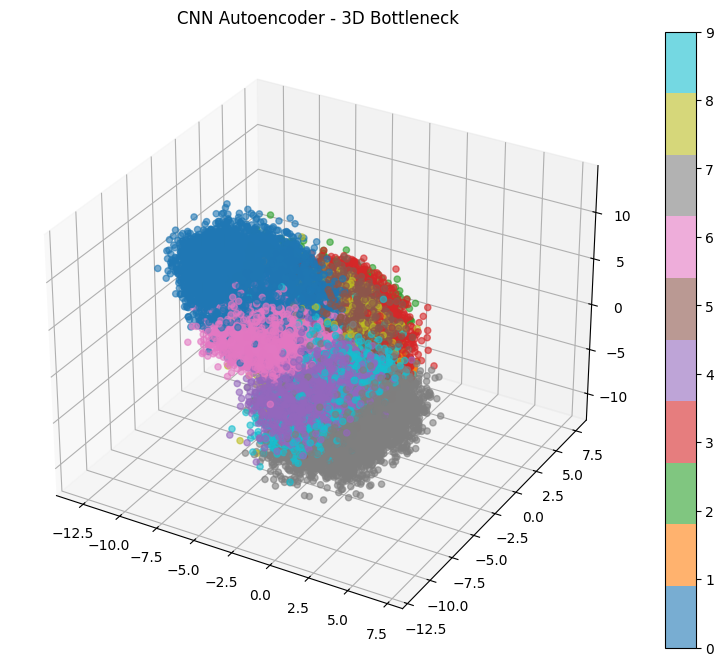

In [20]:
X_encoded_cnn3d = encoder.predict(X_cnn)  # (70000, 3)

y_int = y.astype(int)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(
    X_encoded_cnn3d[:, 0],
    X_encoded_cnn3d[:, 1],
    X_encoded_cnn3d[:, 2],
    c=y_int,
    cmap='tab10',
    alpha=0.6
)
plt.title("CNN Autoencoder - 3D Bottleneck")
plt.colorbar(sc)
plt.show()
